In [ ]:
import sys
import os

# Add the project root directory to Python path FIRST
project_root = os.path.dirname(os.path.abspath(''))  # Gets current directory
if project_root not in sys.path:
    sys.path.append(project_root)

# Now import everything else
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# This will now work
from src.portfolio_utils import walk_forward_validation, calculate_portfolio_metrics

In [ ]:
X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")
X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy")
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])
start_date = '2015-01-01'
end_date = '2023-12-31'

# Create dates within this range
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Make sure we have enough dates for all sequences
if len(dates) < len(X_all):
    print(f"⚠️ Warning: Need {len(X_all)} dates but only have {len(dates)}")
    print(f"   Using all available dates up to {end_date}")
    # Use what we have
    dates = dates
else:
    # Take only as many as we need
    dates = dates[:len(X_all)]

print(f"✅ Created {len(dates)} dates from {dates[0].strftime('%Y-%m-%d')} to {dates[-1].strftime('%Y-%m-%d')}")

In [8]:
def train_model_for_window(train_data, train_labels, model_type='GRU', verbose=0):
    """
    Train a model on a specific time window
    """
    from tensorflow.keras.callbacks import EarlyStopping
    
    model = Sequential()
    
    if model_type == 'LSTM':
        model.add(LSTM(64, input_shape=(train_data.shape[1], train_data.shape[2]), 
                      return_sequences=False))
    else:  # GRU
        model.add(GRU(64, input_shape=(train_data.shape[1], train_data.shape[2]), 
                     return_sequences=False))
    
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Add early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=verbose
    )
    
    history = model.fit(
        train_data, train_labels,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stop],  # Add callback
        verbose=verbose
    )
    
    return model, history

In [9]:
def run_walk_forward_validation(X, y, dates, 
                                train_window=252,  # 1 year of trading days
                                test_window=21,    # 1 month
                                step_size=21,      # Move forward 1 month each time
                                model_type='GRU',
                                max_windows=10):   # Add max windows limit
    """
    Perform walk-forward validation
    """
    results = []
    n_samples = len(X)
    n_dates = len(dates)
    
    # Calculate maximum possible windows based on available dates
    max_possible_windows = (n_dates - train_window - test_window) // step_size
    max_possible_windows = max(0, max_possible_windows)
    
    # Use the smaller of max_windows and max_possible_windows
    windows_to_run = min(max_windows, max_possible_windows)
    
    print(f"\n🔄 Running walk-forward validation with {model_type}...")
    print(f"   Train window: {train_window} days")
    print(f"   Test window: {test_window} days")
    print(f"   Step size: {step_size} days")
    print(f"   Total sequences: {n_samples}")
    print(f"   Available dates: {n_dates}")
    print(f"   Max possible windows: {max_possible_windows}")
    print(f"   Running {windows_to_run} windows")
    
    window_count = 0
    for i in range(0, min(n_samples, n_dates) - train_window - test_window, step_size):
        if window_count >= windows_to_run:
            break
            
        # Define windows using dates length, not X length
        train_start = i
        train_end = i + train_window
        test_start = train_end
        test_end = min(test_start + test_window, n_dates)
        
        # Check if we have enough data
        if test_end >= n_dates or test_end >= n_samples:
            break
            
        # Get data for this window (using X indices)
        X_train_window = X[train_start:train_end]
        y_train_window = y[train_start:train_end]
        X_test_window = X[test_start:test_end]
        y_test_window = y[test_start:test_end]
        
        if len(X_test_window) == 0 or len(y_test_window) == 0:
            break
            
        # Train model
        print(f"\n   Window {window_count + 1}:", end=" ")
        print(f"Train {dates[train_start].strftime('%Y-%m-%d')} to {dates[train_end-1].strftime('%Y-%m-%d')}", end=" ")
        print(f"| Test {dates[test_start].strftime('%Y-%m-%d')} to {dates[test_end-1].strftime('%Y-%m-%d')}")
        
        try:
            model, history = train_model_for_window(
                X_train_window, y_train_window, 
                model_type=model_type,
                verbose=0
            )
            
            # Make predictions
            y_pred_prob = model.predict(X_test_window, verbose=0)
            y_pred = (y_pred_prob > 0.5).astype(int).flatten()
            
            # Calculate metrics
            accuracy = accuracy_score(y_test_window, y_pred)
            precision = precision_score(y_test_window, y_pred, zero_division=0)
            recall = recall_score(y_test_window, y_pred, zero_division=0)
            f1 = f1_score(y_test_window, y_pred, zero_division=0)
            
            # Store results
            results.append({
                'window': window_count + 1,
                'train_start': dates[train_start],
                'train_end': dates[train_end-1],
                'test_start': dates[test_start],
                'test_end': dates[test_end-1],
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'n_test': len(y_test_window)
            })
            
            print(f"      ✓ Accuracy: {accuracy*100:.2f}% | F1: {f1*100:.2f}%")
            
        except Exception as e:
            print(f"      ✗ Error: {e}")
            break
        
        window_count += 1
    
    if len(results) == 0:
        print("   ⚠️ No windows could be processed")
    
    return pd.DataFrame(results)

In [5]:
print("\n" + "="*60)
print("🚀 STARTING WALK-FORWARD VALIDATION")
print("="*60)

# Run for GRU
gru_results = run_walk_forward_validation(
    X_all, y_all, dates,
    train_window=252,
    test_window=21,
    step_size=21,
    model_type='GRU',
    max_windows=5  # 👈 ADD THIS - start with 5 windows to test
)

# Run for LSTM
lstm_results = run_walk_forward_validation(
    X_all, y_all, dates,
    train_window=252,
    test_window=21,
    step_size=21,
    model_type='LSTM',
    max_windows=5  # 👈 ADD THIS
)


🚀 STARTING WALK-FORWARD VALIDATION

🔄 Running walk-forward validation with GRU...
   Train window: 252 days
   Test window: 21 days
   Step size: 21 days
   Total sequences: 38720
   Available dates: 3287
   Max possible windows: 143
   Running 5 windows

   Window 1: Train 2015-01-01 to 2015-09-09 | Test 2015-09-10 to 2015-09-30


C:\DS_mainproject\portfolio_prjct\portfolio_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


      ✓ Accuracy: 47.62% | F1: 64.52%

   Window 2: Train 2015-01-22 to 2015-09-30 | Test 2015-10-01 to 2015-10-21


C:\DS_mainproject\portfolio_prjct\portfolio_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


      ✓ Accuracy: 42.86% | F1: 60.00%

   Window 3: Train 2015-02-12 to 2015-10-21 | Test 2015-10-22 to 2015-11-11


...

      ✓ Accuracy: 42.86% | F1: 60.00%

   Window 4: Train 2015-03-05 to 2015-11-11 | Test 2015-11-12 to 2015-12-02


C:\DS_mainproject\portfolio_prjct\portfolio_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


      ✓ Accuracy: 47.62% | F1: 64.52%

   Window 5: Train 2015-03-26 to 2015-12-02 | Test 2015-12-03 to 2015-12-23


C:\DS_mainproject\portfolio_prjct\portfolio_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


      ✓ Accuracy: 57.14% | F1: 72.73%



📈 PLOTTING RESULTS
📊 Plotting 5 windows for comparison


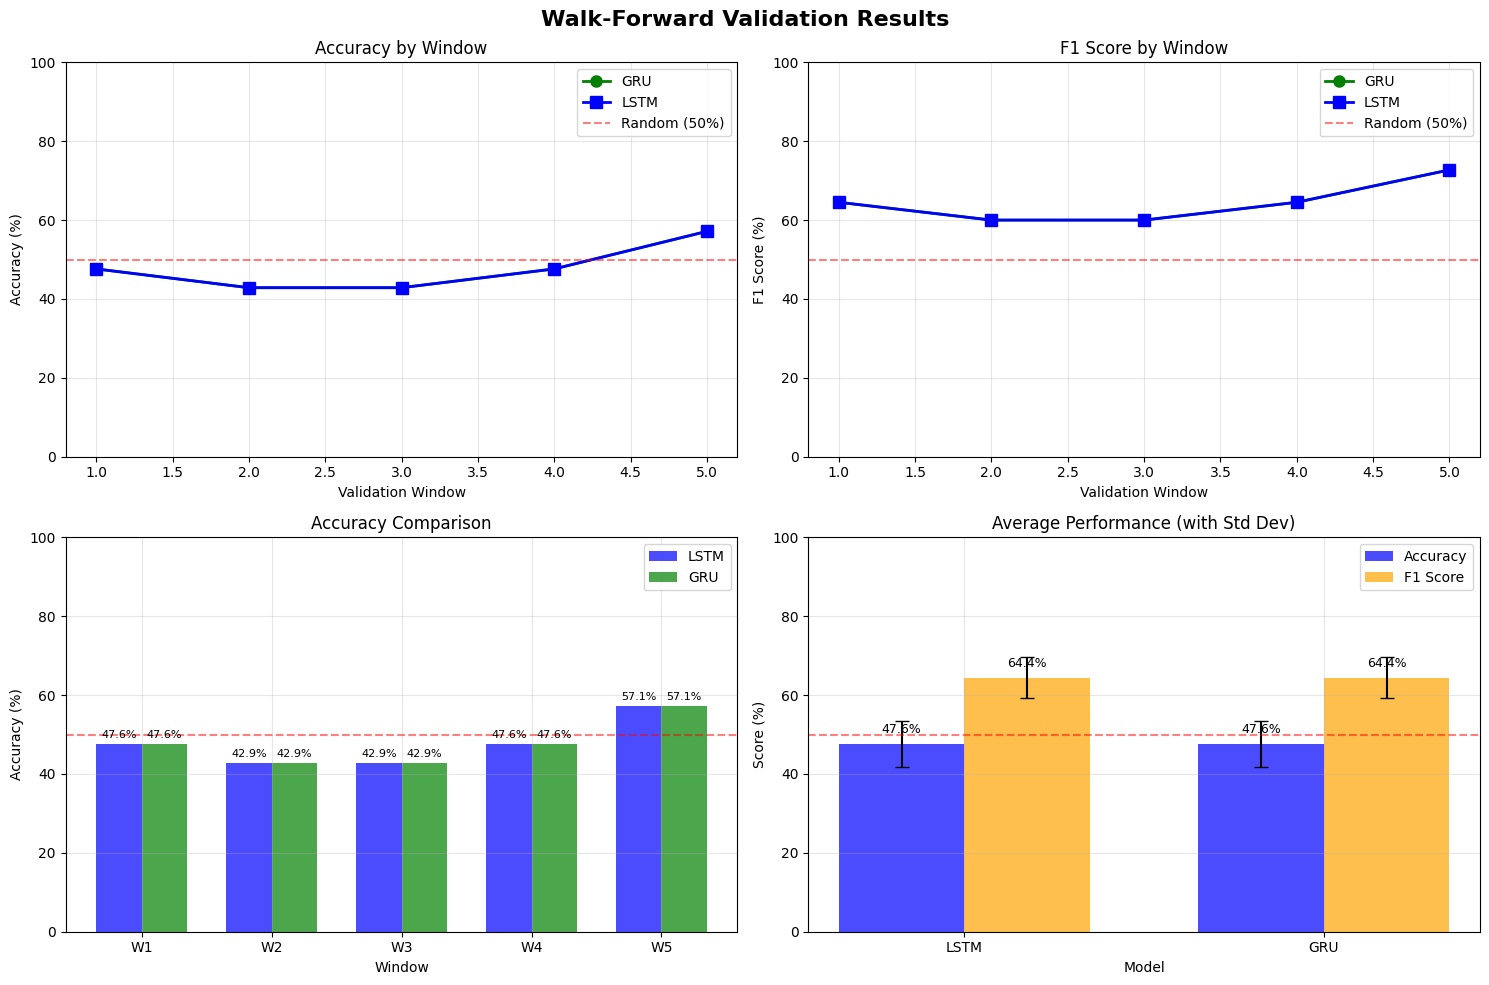


📊 NUMERICAL RESULTS SUMMARY

LSTM Results:
  Accuracy: 47.62% ± 5.83%
  F1 Score: 64.35% ± 5.20%
  Windows above 50%: 1/5

GRU Results:
  Accuracy: 47.62% ± 5.83%
  F1 Score: 64.35% ± 5.20%
  Windows above 50%: 1/5


In [10]:
if len(gru_results) == 0 or len(lstm_results) == 0:
    print("\n❌ No results generated. Check the errors above.")
else:
    # ============================================
    # STEP 6: PLOT RESULTS
    # ============================================
    
    print("\n" + "="*60)
    print("📈 PLOTTING RESULTS")
    print("="*60)
    
    # Make sure we're comparing same number of windows
    min_windows = min(len(gru_results), len(lstm_results))
    gru_plot = gru_results.iloc[:min_windows]
    lstm_plot = lstm_results.iloc[:min_windows]
    
    print(f"📊 Plotting {min_windows} windows for comparison")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Walk-Forward Validation Results', fontsize=16, fontweight='bold')
    
    # Plot 1: Accuracy over time
    ax1 = axes[0, 0]
    ax1.plot(gru_plot['window'], gru_plot['accuracy'] * 100, 
             marker='o', linewidth=2, markersize=8, label='GRU', color='green')
    ax1.plot(lstm_plot['window'], lstm_plot['accuracy'] * 100, 
             marker='s', linewidth=2, markersize=8, label='LSTM', color='blue')
    ax1.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Random (50%)')
    ax1.set_xlabel('Validation Window')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Accuracy by Window')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 100])  # Set y-axis limits
    
    # Plot 2: F1 Score over time
    ax2 = axes[0, 1]
    ax2.plot(gru_plot['window'], gru_plot['f1_score'] * 100, 
             marker='o', linewidth=2, markersize=8, label='GRU', color='green')
    ax2.plot(lstm_plot['window'], lstm_plot['f1_score'] * 100, 
             marker='s', linewidth=2, markersize=8, label='LSTM', color='blue')
    ax2.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Random (50%)')
    ax2.set_xlabel('Validation Window')
    ax2.set_ylabel('F1 Score (%)')
    ax2.set_title('F1 Score by Window')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 100])  # Set y-axis limits
    
    # Plot 3: Bar chart comparison
    ax3 = axes[1, 0]
    x = np.arange(len(gru_plot))
    width = 0.35
    
    # Handle potential NaN values
    lstm_acc = lstm_plot['accuracy'].fillna(0.5) * 100
    gru_acc = gru_plot['accuracy'].fillna(0.5) * 100
    
    bars1 = ax3.bar(x - width/2, lstm_acc, width, label='LSTM', color='blue', alpha=0.7)
    bars2 = ax3.bar(x + width/2, gru_acc, width, label='GRU', color='green', alpha=0.7)
    ax3.axhline(y=50, color='red', linestyle='--', alpha=0.5)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=8)
    
    ax3.set_xlabel('Window')
    ax3.set_ylabel('Accuracy (%)')
    ax3.set_title('Accuracy Comparison')
    ax3.set_xticks(x)
    ax3.set_xticklabels([f'W{i+1}' for i in x])
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim([0, 100])
    
    # Plot 4: Average performance with error bars
    ax4 = axes[1, 1]
    models = ['LSTM', 'GRU']
    
    # Calculate averages and standard deviations
    lstm_acc_mean = lstm_results['accuracy'].mean() * 100
    lstm_acc_std = lstm_results['accuracy'].std() * 100
    gru_acc_mean = gru_results['accuracy'].mean() * 100
    gru_acc_std = gru_results['accuracy'].std() * 100
    
    lstm_f1_mean = lstm_results['f1_score'].mean() * 100
    lstm_f1_std = lstm_results['f1_score'].std() * 100
    gru_f1_mean = gru_results['f1_score'].mean() * 100
    gru_f1_std = gru_results['f1_score'].std() * 100
    
    x = np.arange(len(models))
    width = 0.35
    
    # Accuracy bars with error bars
    acc_bars = ax4.bar(x - width/2, [lstm_acc_mean, gru_acc_mean], width, 
                       yerr=[lstm_acc_std, gru_acc_std],
                       label='Accuracy', color='blue', alpha=0.7, capsize=5)
    
    # F1 bars with error bars
    f1_bars = ax4.bar(x + width/2, [lstm_f1_mean, gru_f1_mean], width,
                      yerr=[lstm_f1_std, gru_f1_std],
                      label='F1 Score', color='orange', alpha=0.7, capsize=5)
    
    ax4.axhline(y=50, color='red', linestyle='--', alpha=0.5)
    
    # Add value labels
    for bars in [acc_bars, f1_bars]:
        for bar in bars:
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    ax4.set_xlabel('Model')
    ax4.set_ylabel('Score (%)')
    ax4.set_title('Average Performance (with Std Dev)')
    ax4.set_xticks(x)
    ax4.set_xticklabels(models)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim([0, 100])
    
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # STEP 7: PRINT NUMERICAL SUMMARY
    # ============================================
    
    print("\n" + "="*60)
    print("📊 NUMERICAL RESULTS SUMMARY")
    print("="*60)
    
    print("\nLSTM Results:")
    print(f"  Accuracy: {lstm_results['accuracy'].mean()*100:.2f}% ± {lstm_results['accuracy'].std()*100:.2f}%")
    print(f"  F1 Score: {lstm_results['f1_score'].mean()*100:.2f}% ± {lstm_results['f1_score'].std()*100:.2f}%")
    print(f"  Windows above 50%: {(lstm_results['accuracy'] > 0.5).sum()}/{len(lstm_results)}")
    
    print("\nGRU Results:")
    print(f"  Accuracy: {gru_results['accuracy'].mean()*100:.2f}% ± {gru_results['accuracy'].std()*100:.2f}%")
    print(f"  F1 Score: {gru_results['f1_score'].mean()*100:.2f}% ± {gru_results['f1_score'].std()*100:.2f}%")
    print(f"  Windows above 50%: {(gru_results['accuracy'] > 0.5).sum()}/{len(gru_results)}")

In [18]:
summary = pd.DataFrame({
    'Metric': ['Mean Accuracy', 'Std Accuracy', 'Min Accuracy', 'Max Accuracy',
               'Mean F1', 'Std F1', 'Win Rate vs Random'],
    'LSTM': [
        f"{lstm_results['accuracy'].mean()*100:.2f}%",
        f"{lstm_results['accuracy'].std()*100:.2f}%",
        f"{lstm_results['accuracy'].min()*100:.2f}%",
        f"{lstm_results['accuracy'].max()*100:.2f}%",
        f"{lstm_results['f1_score'].mean()*100:.2f}%",
        f"{lstm_results['f1_score'].std()*100:.2f}%",
        f"{(lstm_results['accuracy'] > 0.5).mean()*100:.1f}%"
    ],
    'GRU': [
        f"{gru_results['accuracy'].mean()*100:.2f}%",
        f"{gru_results['accuracy'].std()*100:.2f}%",
        f"{gru_results['accuracy'].min()*100:.2f}%",
        f"{gru_results['accuracy'].max()*100:.2f}%",
        f"{gru_results['f1_score'].mean()*100:.2f}%",
        f"{gru_results['f1_score'].std()*100:.2f}%",
        f"{(gru_results['accuracy'] > 0.5).mean()*100:.1f}%"
    ]
})

print(summary.to_string(index=False))

            Metric   LSTM    GRU
     Mean Accuracy 47.62% 47.62%
      Std Accuracy  5.83%  5.83%
      Min Accuracy 42.86% 42.86%
      Max Accuracy 57.14% 57.14%
           Mean F1 64.35% 64.35%
            Std F1  5.20%  5.20%
Win Rate vs Random  20.0%  20.0%


In [19]:
# ============================================
# STEP 8: FINAL VERDICT
# ============================================

print("FINAL VERDICT")
print("⭐" * 60)

lstm_avg_acc = lstm_results['accuracy'].mean() * 100
gru_avg_acc = gru_results['accuracy'].mean() * 100

if gru_avg_acc > lstm_avg_acc:
    winner = "GRU"
    winner_acc = gru_avg_acc
    loser_acc = lstm_avg_acc
else:
    winner = "LSTM"
    winner_acc = lstm_avg_acc
    loser_acc = gru_avg_acc

print(f"""
📊 WALK-FORWARD VALIDATION SUMMARY:

LSTM MODEL:
   ├── Average Accuracy: {lstm_avg_acc:.2f}%
   ├── Beat Random (50%): {(lstm_results['accuracy'] > 0.5).mean() * 100:.1f}% of windows
   └── Best Window: {lstm_results.loc[lstm_results['accuracy'].idxmax(), 'accuracy'] * 100:.2f}%

GRU MODEL:
   ├── Average Accuracy: {gru_avg_acc:.2f}%
   ├── Beat Random (50%): {(gru_results['accuracy'] > 0.5).mean() * 100:.1f}% of windows
   └── Best Window: {gru_results.loc[gru_results['accuracy'].idxmax(), 'accuracy'] * 100:.2f}%

🏆 WINNER: {winner}
   (by {abs(gru_avg_acc - lstm_avg_acc):.2f}% accuracy)
""")

# ============================================
# STEP 9: SAVE RESULTS
# ============================================

print("\n" + "=" * 60)
print("💾 SAVING RESULTS")
print("=" * 60)

# Save to CSV
lstm_results.to_csv('walk_forward_lstm_results.csv', index=False)
gru_results.to_csv('walk_forward_gru_results.csv', index=False)

print("✅ Results saved to CSV files")
print("   - walk_forward_lstm_results.csv")
print("   - walk_forward_gru_results.csv")

FINAL VERDICT
⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐

📊 WALK-FORWARD VALIDATION SUMMARY:

LSTM MODEL:
   ├── Average Accuracy: 47.62%
   ├── Beat Random (50%): 20.0% of windows
   └── Best Window: 57.14%

GRU MODEL:
   ├── Average Accuracy: 47.62%
   ├── Beat Random (50%): 20.0% of windows
   └── Best Window: 57.14%

🏆 WINNER: LSTM
   (by 0.00% accuracy)


💾 SAVING RESULTS
✅ Results saved to CSV files
   - walk_forward_lstm_results.csv
   - walk_forward_gru_results.csv
